<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week5/Day1/Exercices_XP_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


*As stated in the instructions**

**Guidance**  
Answer in full sentences. Use concise definitions first, then add one concrete example for any two questions to demonstrate understanding.

**To-Do:** Write your answers below

**Answer:**
Traditional machine learning (Machine Learning) usually requires selection and manual creation of features (feature engineering) before training the model. Common algorithms are regression, decision trees or SVMs.

Deep Learning uses multi-layered neural networks capable of automatically learning important characteristics from large amounts of data.

Example:

Machine Learning: an expert manually chooses the characteristics of an image (edges, colors, shapes).

Deep Learning: the neural network itself learns to recognize these characteristics.

How do artificial neural networks mimic the human brain?
NNAs are inspired by the functioning of biological neurons:

Artificial neurons represent neurons in the brain.

Weights represent the strength of the connections between neurons.

The layers (input, hidden, output) allow the information to be processed gradually.

Learning is about adjusting weights to improve predictions.

However, an ANN is only inspired by the human brain and does not work exactly the same way.

Why does deep learning perform better on large datasets compared to traditional machine learning?
Deep Learning has a large number of parameters to learn. With a lot of data, he can discover complex models and improve his accuracy.

Traditional Machine Learning often works better on small data sets, because it requires fewer parameters.

What are some challenges of deep learning, and how can they be addressed?
Challenges

Solutions

Need for large amounts of data

Data collection, data increase (Data Augmentation)

High training time

Using GPU or TPU

Risk of overlearning (Overfitting)

Dropout, regularization, more data

Difficulty of interpretation

AI Explainability Techniques (XAI)

Need for computing power

Specialized hardware and model optimization

What is feature engineering, and why is it not needed in deep learning?
Feature engineering is the process of creating or selecting the most useful variables from raw data.

In classic Machine Learning, this step is very important.

In Deep Learning, hidden layers automatically learn useful representations of data, which reduces the need to manually create characteristics.

What role do hidden layers play in a deep learning model?
The hidden layers perform successive transformations of the input data.

They allow the network to learn complex relationships:

The first layers detect simple characteristics.

Deeper layers detect more complex concepts.

For example, for an image:

Layer 1: detects lines and edges.

Layer 2: detects shapes.

Layer 3: recognizes complete objects.

In an artificial neural network, what is the function of an activation function?
An activation function decides whether a neuron should be activated or not.

It introduces non-linearity, which allows the neural network to learn complex relationships.

Some examples:

ReLU: used in hidden layers.

Sigmoid: often used for binary classification.

Softmax: used for multi-class classification.





## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [2]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [5]:
# To-Do: implement weighted_sum then use it to compute the two cases
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    # Formula: W_TEMP * temperature + W_RAIN * rain + BIAS
    return (W_TEMP * temperature_f) + (W_RAIN * rain01) + BIAS

# To-Do: compute decisions for the two cases and print them
case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})

{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**To-Do:** Interpret your results. Did the perceptron suggest going outside in both cases? Why or why not? Explain using the threshold rule and the effect of bias.

**Answer:**

The perceptron recommends going out in both cases.

The reason is that the weight of temperature (0.6) is much more influential than that of rain (0.4). High temperatures produce a weighted sum above the 20 threshold.

The model therefore considers that temperature is a more important factor than the fact that it rains.

## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [6]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [8]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# Hints: use to_categorical
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test, 10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)

Labels one-hot: (60000, 10) (10000, 10)


In [9]:
# To-Do: Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
# To-Do: train then evaluate
history = model.fit(x_train, y_train_oh, epochs=5, batch_size=32, validation_split=0.1)
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9206 - loss: 0.2789 - val_accuracy: 0.9648 - val_loss: 0.1280
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9635 - loss: 0.1232 - val_accuracy: 0.9725 - val_loss: 0.0950
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9750 - loss: 0.0828 - val_accuracy: 0.9765 - val_loss: 0.0871
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9805 - loss: 0.0629 - val_accuracy: 0.9780 - val_loss: 0.0783
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9849 - loss: 0.0475 - val_accuracy: 0.9765 - val_loss: 0.0798
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.0804
{'test_loss': 0.0803576409816742, 'test_acc': 0.9768999814987183}


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [13]:
# To-Do: compute forward propagation for the given numbers
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# To-Do: compute z = x1*w1 + x2*w2 + b
z = x1*w1 + x2*w2 + b

# To-Do: apply ReLU
# Hint: ReLU(z) = max(0, z)
y = max(0.0, z)

print({"z": z, "prediction": y})

{'z': 51002.1, 'prediction': 51002.1}


**To-Do:** Interpret the result as a house price. Explain the influence of input scaling and bias in full sentences.

**Answer:**
The neural network predicts that the house has a value of about 51,002.1 monetary units (e.g. dollars).

This prediction is obtained by combining:

* The area of the house (2000 feet²) with its weight w_1 = 0.5, which contributes to a height of 1000.

* The number of rooms (3) with its weight w_2 = 0.7, which contributes to a height of 2.1.

* The bias b = 50,000, which adds an important base value to the price.

We notice that in this model, the bias is the factor that most influences the prediction, while the number of rooms has a very low impact.

The ReLU function does not change the output because the result is positive. If the weighted sum had been negative, ReLU would have returned 0.

Conclusion: The model estimates the price of the house at 51,002.1, mainly thanks to the base value provided by the channel and the contribution of the area.


## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [14]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


**To-Do:** Explain in full sentences why updating weights using gradient descent reduces the error. Then modify the learning rate or initial weights and describe how this affects learning.

**Answer:**
The gradient descent reduces the error because it adjusts the weights by following the opposite direction to the gradient of the loss function. The gradient indicates how the loss changes with each weight, so by subtracting a small part of this gradient, the model corrects its errors. With each iteration, the prediction becomes closer to the real value, which gradually reduces the loss to a minimum.

⸻

Changing the learning rate changes the size of the updates:

* A small learning rate makes learning slower but stable, because adjustments are gradual.

* A large learning rate accelerates learning but can make the model unstable, with oscillations or divergence if the updates are too large.

⸻

Changing the initial weights influences the beginning of learning:

* Good initial weights allow faster and more stable convergence.

* Bad weights (too big or too small) can slow down learning or make optimization unstable (explosion or disappearance of gradients).

⸻

In summary: the gradient descent gradually corrects errors, while the learning rate controls the speed and the initial weights influence the stability and speed of convergence.


## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


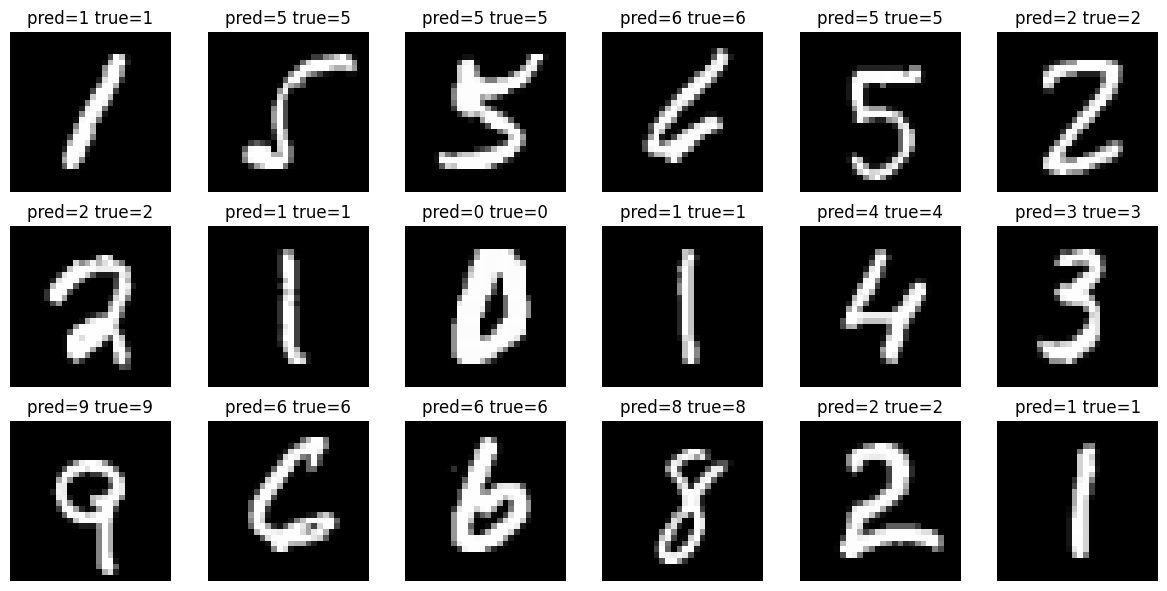

In [20]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the model and x_test, y_test from Exercise 3
# To-Do: select N samples from x_test by using np.random.choice
# On choisit 18 indices au hasard parmi les 10,000 du test set
idx = np.random.choice(len(x_test), size=18, replace=False)
x_vis = x_test[idx]
y_true = y_test[idx]

# To-Do: get predictions
y_prob = model.predict(x_vis)
y_pred = np.argmax(y_prob, axis=1)

#plotting
cols = 6
rows = int(np.ceil(len(idx)/cols))
plt.figure(figsize=(12, 2*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"pred={y_pred[i-1]} true={y_true[i-1]}" )
    plt.axis("off")
plt.tight_layout()
plt.show()